In [1]:
## a nice overview of the fact that sea ice, + other things, are closely coupled to the Arctic temperature.

## Use UKESM ARISE only

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
from nc_processing import grid_cell_areas
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})


#from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds

# get standard variable names, settings for plotting, region bounds etc. 
#from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, UKESM_ARISE_run_IDs, ens_mems_CE, colours, model_colors

## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
#import json
#with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
#    arise_injs = json.load(f)
ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']

assessment_period = [2050, 2069]

lat_band_dict = {'Tropics':[-23, 23], 
                 'Arctic':[66, 91],
                 'Antarctic':[-91, -66],
                 'Global':[-91, 91],
                 'NH':[0, 91],
                 'SH':[-91, 0],
                 'NH_high_lats':[60, 91]}

regions = ['Global', 'Arctic', 'Tropics', 'NH', 'SH', 'Antarctic', 'NH_high_lats']


def spatial_mean(ds, region, zonal_mean=False, var='tas'):
    ds_ts = ds.sel(latitude=slice(lat_band_dict[region][0], lat_band_dict[region][1]))[var]
    if not zonal_mean:
        ds_ts = ds_ts.mean(dim=['longitude'])
    weights = np.cos(np.deg2rad(ds_ts['latitude']))
    ds_ts_w = ds_ts.weighted(weights)
    ds_ts = ds_ts_w.mean(dim='latitude')
    return ds_ts.to_dataset(name=var)

def SI_area_timeseries(ds, perc=True, lat_coord='y', lon_coord='x'):
    ds = ds.rename({lat_coord:'y', lon_coord:'x'})
    ds.load()
    tss = []
    for lat_band in [[-90, 0], [0, 90]]:
        ds_h = ds.sel(y=slice(lat_band[0], lat_band[1]))
        grid_areas = xr.DataArray(
                grid_cell_areas(ds_h.x, ds_h.y),
                dims=['y', 'x'],
                coords=[ds_h.y, ds_h.x]
                ).to_dataset(name='areas')
        SI_area_m2_ds = (ds_h['siconca']*grid_areas['areas']).to_dataset(name='si_area_Mkm2')
        SI_area_Mkm2_ts = SI_area_m2_ds.sum(dim=["x", "y"])*(10**-12)
        if perc==True:
            SI_area_Mkm2_ts = SI_area_Mkm2_ts*(10**-2)
        tss.append(SI_area_Mkm2_ts)
        ds.close()
    return {'SH':tss[0], 'NH':tss[1]}

def snc_area_timeseries(ds, perc=True, lat_coord='y', lon_coord='x'):
    ds = ds.rename({lat_coord:'y', lon_coord:'x'})
    ds.load()
    tss = []
    for lat_band in [[50, 91], [60, 91]]:
        ds_h = ds.sel(y=slice(lat_band[0], lat_band[1]))
        grid_areas = xr.DataArray(
                grid_cell_areas(ds_h.x, ds_h.y),
                dims=['y', 'x'],
                coords=[ds_h.y, ds_h.x]
                ).to_dataset(name='areas')
        snc_area_m2_ds = (ds_h['snc']*grid_areas['areas']).to_dataset(name='snc_area_Mkm2')
        snc_area_Mkm2_ts = snc_area_m2_ds.sum(dim=["x", "y"])*(10**-12)
        if perc==True:
            snc_area_Mkm2_ts = snc_area_Mkm2_ts*(10**-2)
        tss.append(snc_area_Mkm2_ts)
        ds.close()
    return {'snc_50':tss[0], 'snc_60':tss[1]}

In [2]:
### SSP2-4.5 temp
DS_ssp245_tas_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()

### SSP2-4.5 sea ice
DS_ssp245_SI_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='siconca', members=ens_mems_arise_UK, 
                              table='SImon', grid='gr').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()

timeseries_dict_ssp245_tas = dict(zip(regions, [spatial_mean(DS_ssp245_tas_UK, region) for region in regions]))
timeseries_dict_ssp245_SI = SI_area_timeseries(DS_ssp245_SI_UK, lat_coord='latitude', lon_coord='longitude')

ts_ssp245_vars = {'tas':timeseries_dict_ssp245_tas,
                  'siconca':timeseries_dict_ssp245_SI
                  }

OSError: no files to open

In [4]:
ts_ssp245_vars['tas']['Arctic']

<xarray.Dataset> Size: 32kB
Dimensions:          (time: 660, Ensemble_member: 5)
Coordinates:
  * time             (time) object 5kB 2015-01-16 00:00:00 ... 2069-12-16 00:...
    height           float64 8B 1.5
  * Ensemble_member  (Ensemble_member) <U8 160B 'r1i1p1f2' ... 'r8i1p1f2'
Data variables:
    tas              (Ensemble_member, time) float64 26kB 244.9 246.2 ... 259.1

In [5]:
## repeat the above for ARISE:
### ARISE temp
ds_list_tas = []
paths_tas = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/')
for path in paths_tas:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_tas.append(ds)
DS_ARISE_tas = xr.concat(ds_list_tas, dim='Ensemble_member').load()

### get siconca for ARISE
paths_si = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/SImon/siconca/gr/*/')
ds_list_si = []
for path in paths_si:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_si.append(ds)
DS_ARISE_siconca = xr.concat(ds_list_si, dim='Ensemble_member').load()

timeseries_dict_arise_tas = dict(zip(regions, [spatial_mean(DS_ARISE_tas, region) for region in regions]))
timeseries_dict_arise_SI = SI_area_timeseries(DS_ARISE_siconca, lat_coord='latitude', lon_coord='longitude')

In [6]:
### repeat for terrestrial snow cover: 
#os.listdir('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/LImon/snc/gn')

### snc for SSP2-4.5
DS_ssp245_snc = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='snc', members=ens_mems_arise_UK, 
                              table='LImon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()
timeseries_dict_ssp245_snc = snc_area_timeseries(DS_ssp245_snc, lat_coord='latitude', lon_coord='longitude')

### get snc for ARISE
paths_si = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/LImon/snc/gn/*/')
ds_list_snc = []
for path in paths_si:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_snc.append(ds)
DS_ARISE_snc = xr.concat(ds_list_snc, dim='Ensemble_member').load()
timeseries_dict_arise_snc = snc_area_timeseries(DS_ARISE_snc, lat_coord='latitude', lon_coord='longitude')

In [7]:
glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/*mon/tsl/gn/*/')

['/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/Lmon/tsl/gn/v20220325/',
 '/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r2i1p1f2/Lmon/tsl/gn/v20220328/',
 '/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r3i1p1f2/Lmon/tsl/gn/v20220330/',
 '/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r4i1p1f2/Lmon/tsl/gn/v20220401/',
 '/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r8i1p1f2/Lmon/tsl/gn/v20220401/']

In [8]:
## SOIL TEMP as permafrost proxy

### get tas for SSP2-4.5
DS_ssp245_tsl = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tsl', members=ens_mems_arise_UK, 
                              table='Lmon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()

### get tsl for ARISE
paths_tsl = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Lmon/tsl/gn/*/')
ds_list_tsl = []
for path in paths_tsl:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_tsl.append(ds)
DS_ARISE_tsl = xr.concat(ds_list_tsl, dim='Ensemble_member').load()

# use deepest level, which is 2m (bounded at 1-3m depth)
DS_ssp245_tsl = DS_ssp245_tsl.isel(lev=-1)
DS_ARISE_tsl = DS_ARISE_tsl.isel(lev=-1)

timeseries_dict_ssp245_tsl = dict(zip(regions, [spatial_mean(DS_ssp245_tsl, region, var='tsl') for region in regions]))
timeseries_dict_arise_tsl = dict(zip(regions, [spatial_mean(DS_ARISE_tsl, region, var='tsl') for region in regions]))



In [9]:
### lets do Rx1day - takes longer to run
maxpr_members = 5 # set to five for the final run, but might take ~ 10 mins to load in the data

DS_ssp245_pr = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='pr', members=ens_mems_arise_UK[0:maxpr_members], 
                              table='day', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})


### arise
paths_pr = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/day/pr/gn/*/')
ds_list_pr = []
for path in paths_pr:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_pr.append(ds)
DS_ARISE_pr = xr.concat(ds_list_pr[0:maxpr_members], dim='Ensemble_member')


In [10]:

def spatial_mean_rx1day(ds, region='Arctic', zonal_mean=False, var='pr'):
    ds_ts = ds.sel(latitude=slice(lat_band_dict[region][0], lat_band_dict[region][1]))[var]
    ds_ts = ds_ts.groupby('time.year').max(dim='time')
    if not zonal_mean:
        ds_ts = ds_ts.mean(dim=['longitude'])
    weights = np.cos(np.deg2rad(ds_ts['latitude']))
    ds_ts_w = ds_ts.weighted(weights)
    ds_ts = ds_ts_w.mean(dim='latitude')
    return ds_ts.to_dataset(name='rx1day_annual')

In [11]:
ts_arise_pr = spatial_mean_rx1day(DS_ARISE_pr).load()
ts_ssp245_pr = spatial_mean_rx1day(DS_ssp245_pr).load()

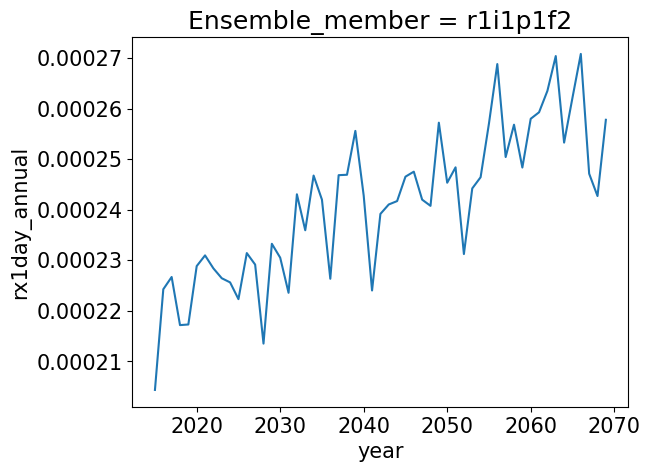

In [12]:
spatial_mean_rx1day(DS_ssp245_pr).isel(Ensemble_member=0).rx1day_annual.plot()

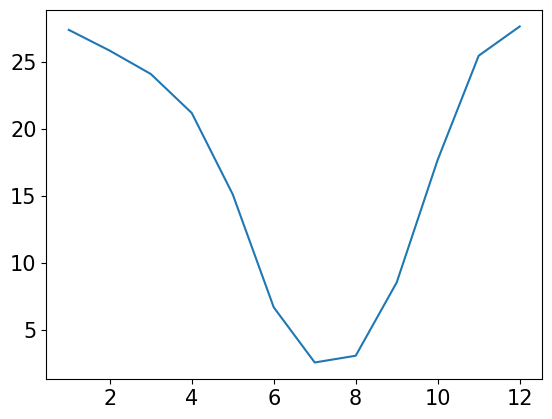

In [13]:
snc = timeseries_dict_arise_snc['snc_50']
snc_seas = snc.groupby('time.month').mean(dim='time')
plt.plot(snc_seas.month, snc_seas.snc_area_Mkm2.mean(dim='Ensemble_member'), label='snc 60N')

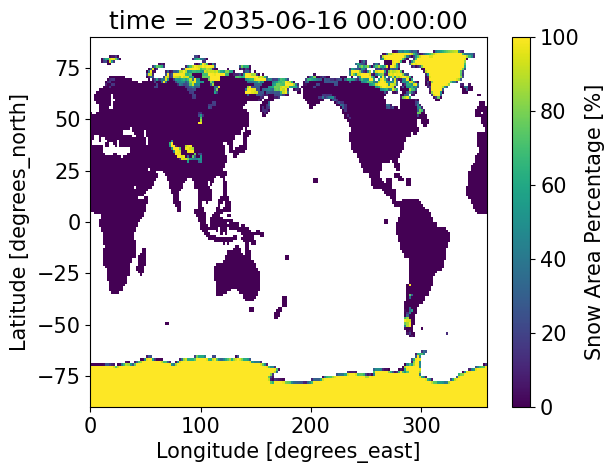

In [14]:
DS_ARISE_snc.isel(Ensemble_member=0).isel(time=5).snc.plot()

In [15]:
#seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
#zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
#amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')



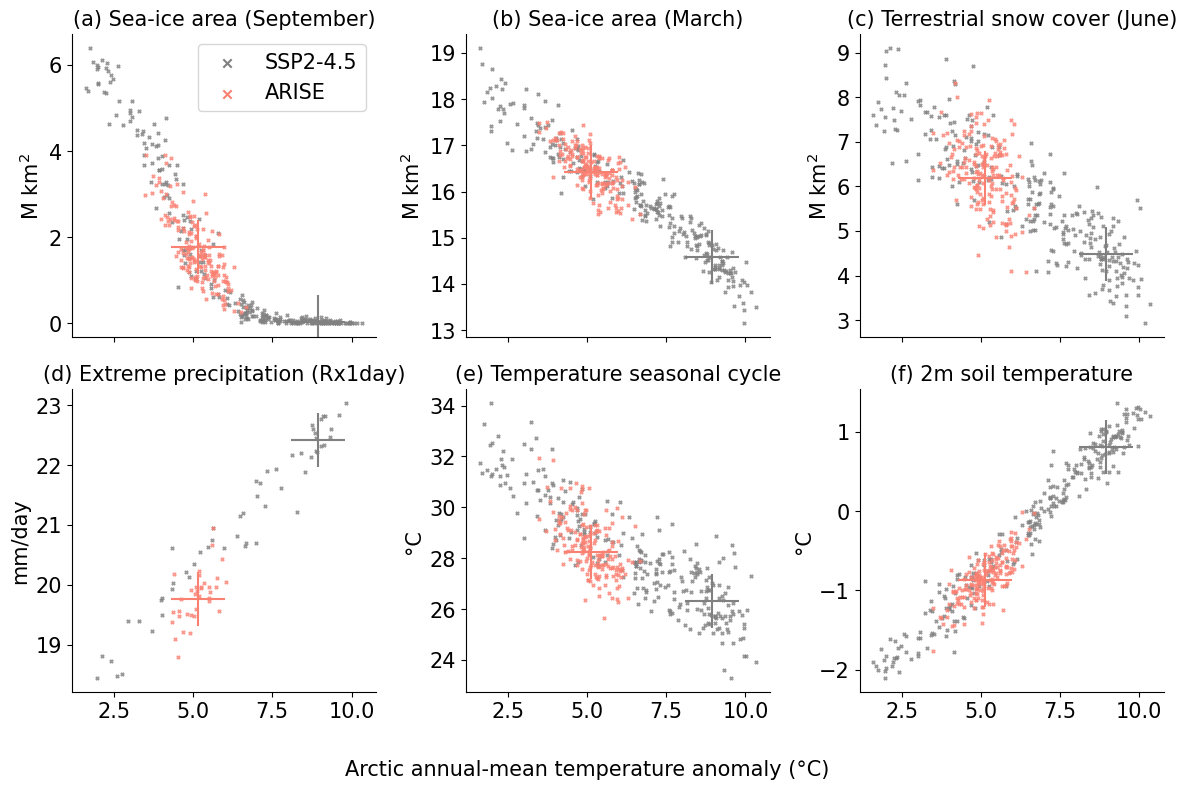

In [36]:
### now plot

fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True)

marker_styles = {'ssp245':'x', 'ARISE':'x'}
colors = {'ssp245':'gray', 'ARISE':'salmon'}
bigsize = 1500
bigmarker = '+'
smallsize = 5
smallalpha = 0.8

#################################################
ax = axs.flatten()[0] # SEP sea ice
month = 9

tas_ts = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').mean('time')
SI_ts = timeseries_dict_ssp245_SI['NH'].where(timeseries_dict_ssp245_SI['NH'].time.dt.month==month, drop=True).groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, SI_ts['si_area_Mkm2'], color=colors['ssp245'], marker=marker_styles['ssp245'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
SI_ts_mn = SI_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, SI_ts_mn['si_area_Mkm2'], color=colors['ssp245'], marker=bigmarker, s=bigsize)

tas_ts = timeseries_dict_arise_tas['Arctic'].groupby('time.year').mean('time')
SI_ts = timeseries_dict_arise_SI['NH'].where(timeseries_dict_arise_SI['NH'].time.dt.month==month, drop=True).groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, SI_ts['si_area_Mkm2'], color=colors['ARISE'], marker=marker_styles['ARISE'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
SI_ts_mn = SI_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, SI_ts_mn['si_area_Mkm2'], color=colors['ARISE'], marker=bigmarker, s=bigsize)
# add legend
ax.scatter([], [], color=colors['ssp245'], label='SSP2-4.5', marker=marker_styles['ssp245'])
ax.scatter([], [], color=colors['ARISE'], label='ARISE', marker=marker_styles['ARISE'])
ax.legend()

#################################################
ax = axs.flatten()[1] # MAR sea ice
month = 3
tas_ts = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').mean('time')
SI_ts = timeseries_dict_ssp245_SI['NH'].where(timeseries_dict_ssp245_SI['NH'].time.dt.month==month, drop=True).groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, SI_ts['si_area_Mkm2'], color=colors['ssp245'], label='SSP2-4.5', marker=marker_styles['ssp245'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
SI_ts_mn = SI_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, SI_ts_mn['si_area_Mkm2'], color=colors['ssp245'], marker=bigmarker, s=bigsize)
tas_ts = timeseries_dict_arise_tas['Arctic'].groupby('time.year').mean('time')
SI_ts = timeseries_dict_arise_SI['NH'].where(timeseries_dict_arise_SI['NH'].time.dt.month==month, drop=True).groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, SI_ts['si_area_Mkm2'], color=colors['ARISE'], label='ARISE', marker=marker_styles['ARISE'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
SI_ts_mn = SI_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, SI_ts_mn['si_area_Mkm2'], color=colors['ARISE'], marker=bigmarker, s=bigsize)


#################################################
ax = axs.flatten()[2] # terrestrial snow cover
month = 6
tas_ts = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').mean('time')
snc_ts = timeseries_dict_ssp245_snc['snc_60'].where(timeseries_dict_ssp245_snc['snc_60'].time.dt.month==month, drop=True).groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, snc_ts['snc_area_Mkm2'], color=colors['ssp245'], label='SSP2-4.5', marker=marker_styles['ssp245'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
snc_ts_mn = snc_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, snc_ts_mn['snc_area_Mkm2'], color=colors['ssp245'], marker=bigmarker, s=bigsize)

tas_ts = timeseries_dict_arise_tas['Arctic'].groupby('time.year').mean('time')
snc_ts = timeseries_dict_arise_snc['snc_60'].where(timeseries_dict_arise_snc['snc_60'].time.dt.month==month, drop=True).groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, snc_ts['snc_area_Mkm2'], color=colors['ARISE'], label='ARISE', marker=marker_styles['ARISE'], s=smallsize, alpha = smallalpha)

# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
snc_ts_mn = snc_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, snc_ts_mn['snc_area_Mkm2'], color=colors['ARISE'], marker=bigmarker, s=bigsize)


#################################################
ax = axs.flatten()[3] # Rx1day
tas_ts = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').mean('time').isel(Ensemble_member=slice(0, maxpr_members)) # NEED TO sel the relevant members here, up to maxpr_members
pr_ts = ts_ssp245_pr
tas_ts, pr_ts = tas_ts.mean('Ensemble_member'), pr_ts.mean('Ensemble_member') # average over members for the noisy pr max data
ax.scatter(tas_ts['tas']-gmst_pi_arctic, 86400*pr_ts['rx1day_annual'], color=colors['ssp245'], label='SSP2-4.5', marker=marker_styles['ssp245'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
#tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean('year')
#pr_ts_mn = pr_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
pr_ts_mn = pr_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean('year')
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, 86400*pr_ts_mn['rx1day_annual'], color=colors['ssp245'], marker=bigmarker, s=bigsize)

tas_ts = timeseries_dict_arise_tas['Arctic'].groupby('time.year').mean('time').isel(Ensemble_member=slice(0, maxpr_members))
pr_ts = ts_arise_pr
tas_ts, pr_ts = tas_ts.mean('Ensemble_member'), pr_ts.mean('Ensemble_member') # average over members for the noisy pr max data
ax.scatter(tas_ts['tas']-gmst_pi_arctic, 86400*pr_ts['rx1day_annual'], color=colors['ARISE'], label='ARISE', marker=marker_styles['ARISE'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
#tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean('year')
#pr_ts_mn = pr_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
pr_ts_mn = pr_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean('year')
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, 86400*pr_ts_mn['rx1day_annual'], color=colors['ARISE'], marker=bigmarker, s=bigsize)

#################################################
ax = axs.flatten()[4] # seasonal amplitude in tas
tas_ts = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').mean('time')
tas_ts_amp = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').max() - timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').min()
ax.scatter(tas_ts['tas']-gmst_pi_arctic, tas_ts_amp['tas'], color=colors['ssp245'], label='SSP2-4.5', marker=marker_styles['ssp245'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
tas_ts_amp_mn = tas_ts_amp.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, tas_ts_amp_mn['tas'], color=colors['ssp245'], marker=bigmarker, s=bigsize)

tas_ts = timeseries_dict_arise_tas['Arctic'].groupby('time.year').mean('time')
tas_ts_amp = timeseries_dict_arise_tas['Arctic'].groupby('time.year').max() - timeseries_dict_arise_tas['Arctic'].groupby('time.year').min()
ax.scatter(tas_ts['tas']-gmst_pi_arctic, tas_ts_amp['tas'], color=colors['ARISE'], label='ARISE', marker=marker_styles['ARISE'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
tas_ts_amp_mn = tas_ts_amp.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, tas_ts_amp_mn['tas'], color=colors['ARISE'], marker=bigmarker, s=bigsize)


#################################################
ax = axs.flatten()[5] # soil temp at 2m
tas_ts = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').mean('time')
tsl_ts = timeseries_dict_ssp245_tsl['NH_high_lats'].groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, tsl_ts['tsl']-273.15, color=colors['ssp245'], label='SSP2-4.5', marker=marker_styles['ssp245'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
tsl_ts_mn = tsl_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, tsl_ts_mn['tsl']-273.15, color=colors['ssp245'], marker=bigmarker, s=bigsize)

tas_ts = timeseries_dict_arise_tas['Arctic'].groupby('time.year').mean('time')
tsl_ts = timeseries_dict_arise_tsl['NH_high_lats'].groupby('time.year').mean('time')
ax.scatter(tas_ts['tas']-gmst_pi_arctic, tsl_ts['tsl']-273.15, color=colors['ARISE'], label='ARISE', marker=marker_styles['ARISE'], s=smallsize, alpha = smallalpha)
# also add a big marker showing the mean over 2050-2070
tas_ts_mn = tas_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
tsl_ts_mn = tsl_ts.sel(year=slice(assessment_period[0], assessment_period[1])).mean(['year', 'Ensemble_member'])
ax.scatter(tas_ts_mn['tas']-gmst_pi_arctic, tsl_ts_mn['tsl']-273.15, color=colors['ARISE'], marker=bigmarker, s=bigsize)


titles = ['(a) Sea-ice area (September)', '(b) Sea-ice area (March)', '(c) Terrestrial snow cover (June)', 
          '(d) Extreme precipitation (Rx1day)', '(e) Temperature seasonal cycle', '(f) 2m soil temperature']
ylabs = ['M km$^2$', 'M km$^2$', 'M km$^2$', 'mm/day', '°C', '°C']
i=0
for ax in axs.flatten():
    #ax.set_xlim(2025, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(titles[i], fontsize='medium')
    ax.set_ylabel(ylabs[i], fontsize='medium')
    i=i+1

fig.supxlabel('Arctic annual-mean temperature anomaly (°C)', fontsize='medium')
    
plt.tight_layout()
plt.savefig('summary_temp_as_proxy.png', bbox_inches='tight', dpi=300)

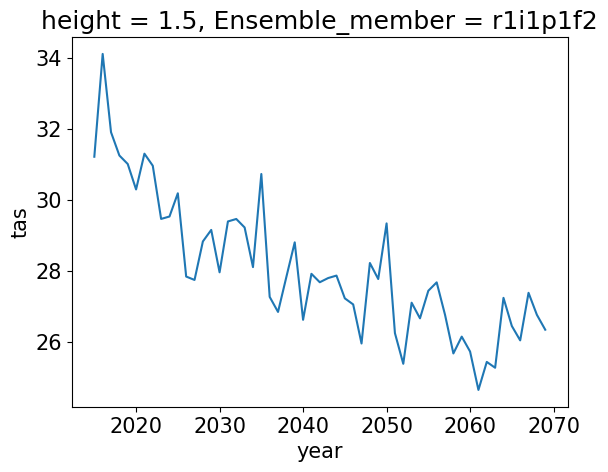

In [ ]:
tas_ts_amp = timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').max() - timeseries_dict_ssp245_tas['Arctic'].groupby('time.year').min()
tas_ts_amp.isel(Ensemble_member=0).tas.plot()

In [24]:

### first get PI gmst:
def get_gmst(model, region=None):
    dir_pi = glob.glob('/badc/cmip6/data/CMIP6/*/*/{}/piControl/r1i*/Amon/tas/*/latest/'.format(model))
    files_pi = os.listdir(dir_pi[0])[0:3] # don't need the full length run
    paths_pi = []
    for x in files_pi:
        paths_pi.append(dir_pi[0]+x)
    da_pi = rename_cmip6(xr.open_mfdataset(paths_pi)).tas.mean(dim='x')
    if region is not None:
        da_pi = da_pi.sel(y=slice(lat_band_dict[region][0], lat_band_dict[region][1]))
    da_pi = da_pi.weighted(weights=np.cos(np.deg2rad(da_pi.y))).mean(dim='y')
    
    gmst_pi = da_pi.mean(dim='time').values
    print(gmst_pi)
    return gmst_pi

gmst_pi = get_gmst('UKESM1-0-LL')
gmst_pi_arctic = get_gmst('UKESM1-0-LL', region='Arctic')

286.52036529129015
257.78859373090165
